In [1]:
import sys
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from scipy.stats import hypergeom
from sklearn.metrics import pairwise_distances
from itertools import combinations

from sklearn.manifold import MDS,Isomap,TSNE
from sklearn.cluster import AffinityPropagation,AgglomerativeClustering

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large'}) 
from matplotlib.backends.backend_pdf import PdfPages

import sys
import os

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

from adjustText import adjust_text
import umap

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h3>Load data</h3>

In [2]:
reload(util_functions)
input_file = "/project/shared/gcrb_igvf/data/shared/TF_Perturbseq_full/H5AD/V0.1_TF_Perturbseq_full_sgRNACells_filtered_w_embedding_full_dataset.h5ad"
sgRNA_file = "/project/GCRB/Hon_lab/s215194/Single_Cell/TF_perturbseq_full/_all_lanes_combined/aggr_dataframe/aggr_combined_df_full.pkl"
dict_file = "./gRNA_dict.pickle"
pca_file = "./pca_dataframe.pickle"
non_target_file = "./non_target_cell_name.pickle"

obsm_key = "X_pca"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
            
(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,dict_file,pca_file,obsm_key)

read input
read pickle
read from dictionary


In [3]:
gRNA_per_transcript_dict = {}
cell_per_transcript_dict = {}

cell_num_dict_gRNA = {}

for key in gRNA_dict.keys():
    transcript_name = util_functions.extract_transcript_name(key)

    num_cell = len(gRNA_dict[key])
    cell_num_dict_gRNA[key] = num_cell
    
    if num_cell > 20:
        if transcript_name in gRNA_per_transcript_dict.keys():
            gRNA_per_transcript_dict[transcript_name] += [key].copy()
            cell_per_transcript_dict[transcript_name] += gRNA_dict[key].copy()
        else:
            gRNA_per_transcript_dict[transcript_name] = [key].copy()
            cell_per_transcript_dict[transcript_name] = gRNA_dict[key].copy()

<h3>Aggregate. Use anova based method</h3>

In [4]:
sgRNA_sig_outlier_df = pd.read_csv("sgRNA_outlier_dist_clear_v3.csv",index_col=0)
sgRNA_sig_outlier_df["gene_name"] = [util_functions.extract_gene_name(key) 
                                     for key in sgRNA_sig_outlier_df.index.to_list()]

pval_sig_df = pd.read_csv("p_val_gRNA_sig_full_expressing_v3.csv",index_col=0)

In [5]:
gene_list = np.unique(pval_sig_df["gene_name"])

In [6]:
cell_id_list_gene = []
for target_gene in gene_list:
    sgRNA_names = sgRNA_sig_outlier_df[sgRNA_sig_outlier_df["gene_name"]==target_gene].index.to_list()

    cell_id_total = np.concatenate([gRNA_dict[name] for name in sgRNA_names])
    cell_id_total = np.unique(cell_id_total)
    cell_id_list_gene += [cell_id_total]

In [7]:
!nvidia-smi

Sat Jun 22 19:21:26 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           Off |   00000000:3B:00.0 Off |                    0 |
| N/A   27C    P0             26W /  250W |     187MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
res = util_functions.pairwise_torch(X,cell_id_list_gene,
                                    device,
                                    batch_size=20)

100%|██████████| 1097/1097 [00:39<00:00, 27.48it/s]


In [9]:
pairwise_dict=dict(zip(gene_list,[" "]*len(gene_list)))
for key in pairwise_dict.keys():
    pairwise_dict[key] = dict(zip(gene_list,[" "]*len(gene_list)))

for p1, p2, val in tqdm(res):
    p1_name = gene_list[int(p1)]
    p2_name = gene_list[int(p2)]
    
    pairwise_dict[p1_name][p2_name]=val
    pairwise_dict[p2_name][p1_name]=val
df = pd.DataFrame(pairwise_dict,index=gene_list,columns=gene_list) 

df.index.name = "sgRNA"
df.columns.name = "sgRNA"
df.name = 'pairwise PCA distances'

sigmas = np.diag(df)
deltas = df
target_estats = 2 * deltas - sigmas - sigmas[:, np.newaxis]
target_estats = target_estats.abs()

100%|██████████| 21945/21945 [00:00<00:00, 1392201.37it/s]


In [10]:
target_estats

sgRNA,ADNP2,AFF4,AHCY,AHDC1,APITD1,AR,ARID2,ARID3A,ARID3B,ARID4B,...,ZNF746,ZNF782,ZNF787,ZNF8,ZNF814,ZNF844,ZNF91,ZSCAN10,ZSCAN20,ZSCAN32
sgRNA,,,,,,,,,,,,,,,,,,,,,
ADNP2,0.000000,21.723633,20.441284,53.992920,43.270386,76.470825,42.433838,34.998169,48.084473,69.697388,...,53.347046,67.416565,34.013428,52.858276,63.979980,65.125244,55.335205,58.982056,64.883057,64.429199
AFF4,21.723633,0.000000,7.592163,47.288818,18.346558,48.196655,17.418457,30.855591,31.533447,40.070679,...,28.488647,40.413391,13.863037,31.923462,42.171143,43.316650,29.296143,67.880005,35.549561,42.448486
AHCY,20.441284,7.592163,0.000000,42.233521,20.819336,53.111084,31.855835,31.708496,30.734985,49.285645,...,29.999512,45.136902,25.020874,31.052002,39.802856,39.901733,29.295776,85.484863,38.608765,47.837769
AHDC1,53.992920,47.288818,42.233521,0.000000,24.609985,23.032349,58.189697,22.744751,18.980225,33.919556,...,23.127808,23.398987,96.354736,19.322388,15.187256,16.294189,20.604248,175.707397,22.978271,22.726562
APITD1,43.270386,18.346558,20.819336,24.609985,0.000000,12.004639,30.756226,16.635498,8.630493,14.146240,...,4.114014,7.607117,54.839233,4.740479,9.696167,9.671997,3.845581,132.947998,5.914917,10.574585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF844,65.125244,43.316650,39.901733,16.294189,9.671997,8.681763,58.192627,24.170532,10.219482,16.287964,...,6.205444,9.515198,93.677979,3.488159,6.947510,0.000000,4.776855,192.802124,9.461670,8.730469
ZNF91,55.335205,29.296143,29.295776,20.604248,3.845581,6.410522,41.577148,21.246704,9.048340,12.682983,...,3.340210,5.552063,73.335449,2.576050,7.008789,4.776855,0.000000,164.649048,5.259766,7.176514
ZSCAN10,58.982056,67.880005,85.484863,175.707397,132.947998,193.669189,74.461060,120.555420,152.180786,159.329834,...,158.312012,172.824890,46.805054,164.163574,179.679810,192.802124,164.649048,0.000000,167.142456,179.142456


In [11]:
target_estats.to_csv("gene_estat_v3.csv")

In [12]:
sns.clustermap(target_estats,figsize=(80,80),vmax=100)
plt.savefig("gene_heatmap_v3.pdf")

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage 

In [13]:
index_list = np.array(target_estats.index.tolist())
target_name_list = ["ARNT","HIF1A","CREBBP","EP300","FOS","JUN"]
test_tf_index_list = []

for target_name in target_name_list:
    print(target_name,np.where(np.char.startswith(index_list,target_name)))
    test_tf_index_list.append(np.where(np.char.startswith(index_list,target_name))[0][0])
    
def get_cluster_score(cluster_list):
    return_list = [False,False,False,False,False,False]
    # print(cluster_list[4],cluster_list[30],
    #       cluster_list[17],cluster_list[22],
    #       cluster_list[94],cluster_list[19]
    #      )
    if ((cluster_list[test_tf_index_list[0]] == cluster_list[test_tf_index_list[1]]) and 
        (cluster_list[test_tf_index_list[0]] != -1)):
        return_list[0] = True
        
    if ((cluster_list[test_tf_index_list[2]] == cluster_list[test_tf_index_list[3]]) and 
        (cluster_list[test_tf_index_list[2]] != -1)):
        return_list[1] = True
        
    if ((cluster_list[test_tf_index_list[4]] == cluster_list[test_tf_index_list[5]]) and
        (cluster_list[test_tf_index_list[4]] != -1)):
        return_list[2] = True
    
    if ((cluster_list[test_tf_index_list[0]] != cluster_list[test_tf_index_list[2]]) and 
        (cluster_list[test_tf_index_list[0]] != -1) and 
        (cluster_list[test_tf_index_list[2]] != -1)):
        return_list[3] = True
        
    if ((cluster_list[test_tf_index_list[0]] != cluster_list[test_tf_index_list[4]]) and 
        (cluster_list[test_tf_index_list[0]] != -1) and 
        (cluster_list[test_tf_index_list[4]] != -1)):
        return_list[4] = True
        
    if ((cluster_list[test_tf_index_list[2]] != cluster_list[test_tf_index_list[4]]) and 
        (cluster_list[test_tf_index_list[2]] != -1) and 
        (cluster_list[test_tf_index_list[4]] != -1)):
        return_list[5] = True
    return return_list

ARNT (array([10]),)
HIF1A (array([52]),)
CREBBP (array([25]),)
EP300 (array([36]),)
FOS (array([41]),)
JUN (array([60]),)


<H3>Isomap +Affinity</H3>

In [14]:
output_list = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for num_neigh in tqdm(range(2,5)):
        for n_comp in range(2,70,2):
            fit_method_for_cluster = Isomap(n_components=n_comp, n_neighbors=num_neigh,
                                            metric="precomputed")
            embedding_for_cluster = fit_method_for_cluster.fit_transform(target_estats.copy())

            for damp_val in range(50,100,10):
                clustering_method_emb= AffinityPropagation(random_state=0,convergence_iter=15,
                                                            damping=damp_val/100,
                                                            max_iter=500)

                cluster_info_emb = clustering_method_emb.fit(embedding_for_cluster)

                num_cluster = np.sum(np.unique(cluster_info_emb.labels_) != -1)
                clustering_score = np.sum(get_cluster_score(cluster_info_emb.labels_))
                output_list.append([num_neigh,n_comp,damp_val,num_cluster,cluster_info_emb.n_iter_,clustering_score])

100%|██████████| 3/3 [00:27<00:00,  9.23s/it]


In [15]:
clust_num_df = pd.DataFrame(output_list,columns=["num_neigh","n_comp","damp_val","cluster_num","iter_num","cluster_score"])
clust_num_df.head()

,num_neigh,n_comp,damp_val,cluster_num,iter_num,cluster_score
0,2,2,50,14,164,6
1,2,2,60,15,76,6
2,2,2,70,14,36,5
3,2,2,80,13,33,5
4,2,2,90,3,16,3


In [16]:
for col_name in clust_num_df.columns[:-3].values:
    print(col_name)
    unique_res = np.unique(clust_num_df[clust_num_df["cluster_score"]==6][col_name],
                  return_counts=True)
    print(unique_res[0])
    print(unique_res[1])

num_neigh
[2 3 4]
[150  95 102]
n_comp
[ 2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48
 50 52 54 56 58 60 62 64 66 68]
[ 8  1  5  9  8  9 14 10 10 11 13 13 12 12 13 13  8 10  9 13 13 14 13 11
 10  9  7  9 10 10 10 10 10 10]
damp_val
[50 60 70 80 90]
[71 71 83 83 39]


In [17]:
unique_res = np.unique(clust_num_df[(clust_num_df["cluster_score"]==6) &
                                    (clust_num_df["num_neigh"]==2)
                                   ]["n_comp"],return_counts=True)
print(unique_res[0])
print(unique_res[1])

[ 2  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50
 52 54 56 58 60 62 64 66 68]
[2 5 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 4 5 5 5 5 5 5 5 5 5 5 5 5 4 5 5]


In [18]:
clust_num_df[(clust_num_df["num_neigh"]==2) &
             (clust_num_df["n_comp"]==60)
            ]

,num_neigh,n_comp,damp_val,cluster_num,iter_num,cluster_score
145,2,60,50,29,61,6
146,2,60,60,29,78,6
147,2,60,70,30,105,6
148,2,60,80,30,154,6
149,2,60,90,27,82,6


In [19]:
#clustering using best parameter
fit_method_for_cluster = Isomap(n_neighbors=2, n_components=60, metric="precomputed")
embedding_for_cluster = fit_method_for_cluster.fit_transform(target_estats.copy())

clustering_method_emb = AffinityPropagation(random_state=0,convergence_iter=15,damping=0.50)
#clustering_method_emb = AgglomerativeClustering(n_clusters=25,linkage="ward")

cluster_info_emb = clustering_method_emb.fit(embedding_for_cluster)

In [20]:
for cluster_index in np.unique(cluster_info_emb.labels_):
    tf_index_cluster = np.argwhere(cluster_info_emb.labels_ == cluster_index).reshape(-1)
    print(cluster_index,index_list[tf_index_cluster])

0 ['ARNT' 'HIF1A']
1 ['BRPF1']
2 ['AFF4' 'ARID2' 'CHD7' 'CNBP' 'DNAJC19' 'HMG20A' 'KLF12' 'MAFB' 'MBD6'
 'RARA' 'SMAD2' 'SMAD3' 'SMAD4' 'SOX4' 'SUPT4H1' 'TBX5' 'TCEB3' 'YWHAE'
 'ZBTB12' 'ZC3H15' 'ZFPM2' 'ZIC2' 'ZNF384']
3 ['EOMES']
4 ['GATA4']
5 ['GATAD1']
6 ['KMT2A']
7 ['CHAMP1' 'GTF2I' 'ISL1' 'MEF2A' 'MEF2C']
8 ['ATMIN' 'MEF2D' 'MTF2' 'MYOCD' 'PCGF6' 'RNF2' 'ZNF787']
9 ['MIXL1']
10 ['NKX2-5']
11 ['BPTF' 'DNTTIP1' 'ESRRA' 'ETS1' 'EZH1' 'KDM5B' 'NOTCH2' 'PCGF2' 'PHF21A'
 'SMAD6' 'TOPORS' 'ZEB2']
12 ['RCOR2']
13 ['BOLA3' 'CDX1' 'CRAMP1L' 'DEK' 'ELMSAN1' 'FOXI3' 'GATA6' 'GLI3' 'KCNIP3'
 'KLF10' 'MAPK8IP1' 'NFIL3' 'OVOL2' 'PURA' 'RFX7' 'RUNX2' 'TBX2' 'ZNF331'
 'ZNF391' 'ZNF41' 'ZNF425' 'ZNF71']
14 ['SETDB1']
15 ['SMAD5']
16 ['SMARCA4']
17 ['SOX11']
18 ['TADA2B' 'TAF12' 'TAF4']
19 ['TBX20']
20 ['CAMTA2' 'LZTR1' 'PIN1' 'SP8' 'TCF7' 'TFAP4' 'ZNF518B']
21 ['YAP1']
22 ['DOT1L' 'HOXB4' 'MEIS1' 'ZBTB10']
23 ['ZC3H3']
24 ['ID2' 'LEF1' 'MSX2' 'MTF1' 'MYCN' 'PLAGL1' 'RARG' 'RB1' 'RB1CC1' 'RBL2'
 'S

<h3>Use the best clustering parameter +visualization </h3>

In [21]:
fit_method_for_cluster = Isomap(n_neighbors=2, n_components=60, metric="precomputed")
embedding_for_cluster = fit_method_for_cluster.fit_transform(target_estats.copy())

clustering_method_emb = AffinityPropagation(random_state=0,convergence_iter=15,damping=0.50)

cluster_info_emb = clustering_method_emb.fit(embedding_for_cluster)

In [22]:
fit_method = TSNE(n_components=2, perplexity=2,n_iter=5000,random_state=1,
                  init="random",metric="precomputed")

embedding = fit_method.fit_transform(target_estats.copy())
# fit_method = TSNE(n_components=2, perplexity=2,n_iter=5000,random_state=1,
#                   init="random")
# embedding = fit_method.fit_transform(embedding_for_cluster)


total_edist_umap=pd.DataFrame(embedding,index=target_estats.index,columns=["x","y"]).reset_index()
# total_edist_umap["cluster"]=cluster_info.labels_
total_edist_umap["cluster"]=cluster_info_emb.labels_

In [23]:
for cluster_index in np.unique(total_edist_umap["cluster"]):
    print(cluster_index,total_edist_umap[total_edist_umap["cluster"]==cluster_index]["sgRNA"].tolist())

0 ['ARNT', 'HIF1A']
1 ['BRPF1']
2 ['AFF4', 'ARID2', 'CHD7', 'CNBP', 'DNAJC19', 'HMG20A', 'KLF12', 'MAFB', 'MBD6', 'RARA', 'SMAD2', 'SMAD3', 'SMAD4', 'SOX4', 'SUPT4H1', 'TBX5', 'TCEB3', 'YWHAE', 'ZBTB12', 'ZC3H15', 'ZFPM2', 'ZIC2', 'ZNF384']
3 ['EOMES']
4 ['GATA4']
5 ['GATAD1']
6 ['KMT2A']
7 ['CHAMP1', 'GTF2I', 'ISL1', 'MEF2A', 'MEF2C']
8 ['ATMIN', 'MEF2D', 'MTF2', 'MYOCD', 'PCGF6', 'RNF2', 'ZNF787']
9 ['MIXL1']
10 ['NKX2-5']
11 ['BPTF', 'DNTTIP1', 'ESRRA', 'ETS1', 'EZH1', 'KDM5B', 'NOTCH2', 'PCGF2', 'PHF21A', 'SMAD6', 'TOPORS', 'ZEB2']
12 ['RCOR2']
13 ['BOLA3', 'CDX1', 'CRAMP1L', 'DEK', 'ELMSAN1', 'FOXI3', 'GATA6', 'GLI3', 'KCNIP3', 'KLF10', 'MAPK8IP1', 'NFIL3', 'OVOL2', 'PURA', 'RFX7', 'RUNX2', 'TBX2', 'ZNF331', 'ZNF391', 'ZNF41', 'ZNF425', 'ZNF71']
14 ['SETDB1']
15 ['SMAD5']
16 ['SMARCA4']
17 ['SOX11']
18 ['TADA2B', 'TAF12', 'TAF4']
19 ['TBX20']
20 ['CAMTA2', 'LZTR1', 'PIN1', 'SP8', 'TCF7', 'TFAP4', 'ZNF518B']
21 ['YAP1']
22 ['DOT1L', 'HOXB4', 'MEIS1', 'ZBTB10']
23 ['ZC3H3']
24 ['ID2

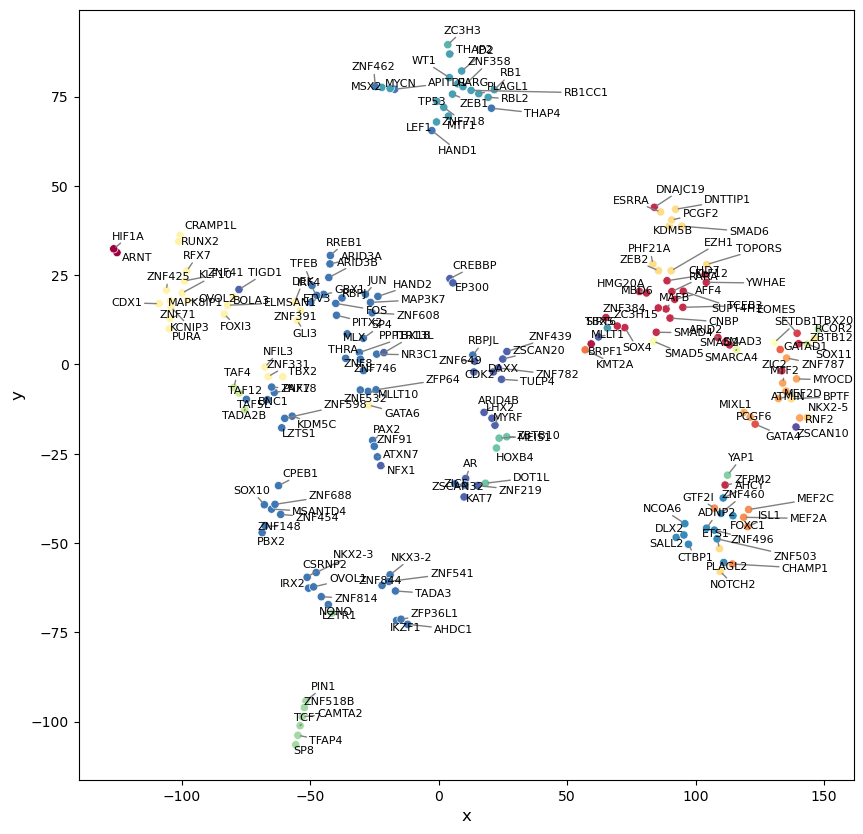

In [24]:
total_edist_umap_tmp = total_edist_umap.copy()

fig,ax= plt.subplots(figsize=(10,10)) 

sns.scatterplot(data=total_edist_umap_tmp,x="x",y="y",ax=ax,hue="cluster",
                palette=sns.color_palette("Spectral", as_cmap=True),legend=None)
texts = []
for index,row in total_edist_umap_tmp.iterrows():
    plt_text = ax.annotate(row["sgRNA"], (row["x"], row["y"]), fontsize=8, color='black')   
    texts.append(plt_text)
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=1),force_text=(0.5, 0.5))
plt.savefig("gene_estat_emb_tsne.pdf")

In [25]:
total_edist_umap.to_csv("gene_estat_emb_tsne_data.csv")